<a href="https://colab.research.google.com/github/w1911922-cell/CRM-COURSEWORK-2/blob/main/CRM_TaskAQuestionG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-p5489akw
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-p5489akw
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# numpy and pandas will be used for data manipulation
import numpy as np
import pandas as pd

# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt

# Yfinance will be used for importing historical oil prices
import yfinance as yfin

In [3]:
# Setting our ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)

# Importing our data
data = ticker.history(period='5y')

<Axes: xlabel='Date', ylabel='Amazon Stock Prices'>

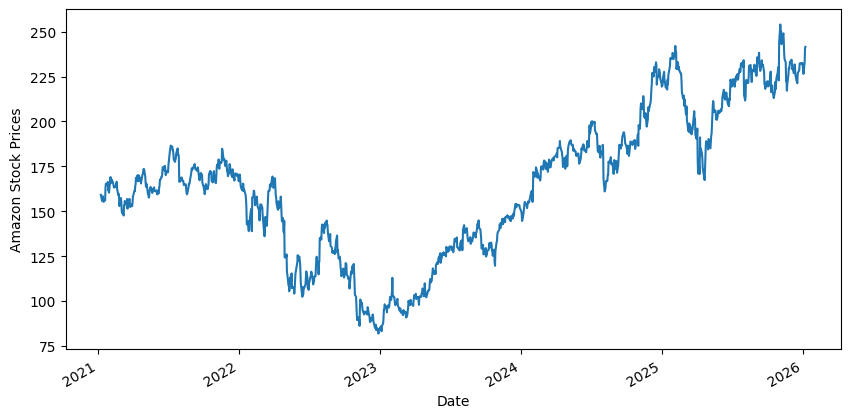

In [4]:
# Setting the text on the Y-axis
plt.ylabel("Amazon Stock Prices")

# Setting the size of our graph
data['Close'].plot(figsize=(10,5))

In [5]:
data['MA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['MA_50']= data['Close'].shift(1).rolling(window=50).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

In [6]:
data.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_20,MA_50,EMA_20
Date,,,,,,,,,,
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0,NaN,NaN,159.134995
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0,NaN,NaN,158.808852
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0,NaN,NaN,158.545295
2021-01-13 00:00:00-05:00,156.421997,159.497498,156.104004,158.294495,66424000,0.0,0.0,NaN,NaN,158.521409
2021-01-14 00:00:00-05:00,158.376007,158.899994,156.029495,156.373505,61418000,0.0,0.0,NaN,NaN,158.316847
2021-01-15 00:00:00-05:00,156.151001,157.127502,154.758499,155.212494,84880000,0.0,0.0,NaN,NaN,158.021194
2021-01-19 00:00:00-05:00,155.350006,157.250000,154.800003,156.037994,66102000,0.0,0.0,NaN,NaN,157.832318
2021-01-20 00:00:00-05:00,159.099503,163.990005,158.750000,163.169006,106196000,0.0,0.0,NaN,NaN,158.340574
2021-01-21 00:00:00-05:00,164.649994,167.427505,164.478500,165.349503,98722000,0.0,0.0,NaN,NaN,159.008091


In [7]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['EMA_20','MA_50']]

# Getting the head of the data
X.head()

,EMA_20,MA_50
Date,,
2021-03-23 00:00:00-04:00,155.266273,159.13105
2021-03-24 00:00:00-04:00,155.179343,159.08585
2021-03-25 00:00:00-04:00,154.906358,159.05871
2021-03-26 00:00:00-04:00,154.686848,158.98414
2021-03-29 00:00:00-04:00,154.601100,158.87028


In [8]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the feature variables
X = data[['MA_20','EMA_20','MA_50', 'Close']]

# Getting the head of the data
X.head()

,MA_20,EMA_20,MA_50,Close
Date,,,,
2021-03-23 00:00:00-04:00,153.816077,155.266273,159.13105,156.875000
2021-03-24 00:00:00-04:00,153.673576,155.179343,159.08585,154.353500
2021-03-25 00:00:00-04:00,153.492426,154.906358,159.05871,152.313004
2021-03-26 00:00:00-04:00,153.465176,154.686848,158.98414,152.601501
2021-03-29 00:00:00-04:00,153.362926,154.601100,158.87028,153.786499


In [9]:
# Setting the training set to 70% of the data
training = 0.7
t = int(training*len(X))

# Training dataset
data_train= X[:t]

# Testing dataset
data_test = X[t:]

In [10]:
X[:t]

,MA_20,EMA_20,MA_50,Close
Date,,,,
2021-03-23 00:00:00-04:00,153.816077,155.266273,159.131050,156.875000
2021-03-24 00:00:00-04:00,153.673576,155.179343,159.085850,154.353500
2021-03-25 00:00:00-04:00,153.492426,154.906358,159.058710,152.313004
2021-03-26 00:00:00-04:00,153.465176,154.686848,158.984140,152.601501
2021-03-29 00:00:00-04:00,153.362926,154.601100,158.870280,153.786499
...,...,...,...,...
2024-07-23 00:00:00-04:00,193.123500,189.963403,187.558800,186.410004
2024-07-24 00:00:00-04:00,193.165500,189.093555,187.497000,180.830002
2024-07-25 00:00:00-04:00,192.890000,188.213217,187.364001,179.850006


In [11]:
X[t:]

,MA_20,EMA_20,MA_50,Close
Date,,,,
2024-07-30 00:00:00-04:00,190.932000,186.716476,187.082400,181.710007
2024-07-31 00:00:00-04:00,190.157500,186.741573,187.044000,186.979996
2024-08-01 00:00:00-04:00,189.506500,186.487138,187.089600,184.070007
2024-08-02 00:00:00-04:00,188.830501,184.716934,187.100201,167.899994
2024-08-05 00:00:00-04:00,187.225500,182.460083,186.795201,161.020004
...,...,...,...,...
2025-12-31 00:00:00-05:00,228.952500,229.774434,231.150000,230.820007
2026-01-02 00:00:00-05:00,228.772501,229.462584,231.436801,226.500000
2026-01-05 00:00:00-05:00,228.478500,229.805194,231.526201,233.059998


In [12]:
from pycaret.regression import *
s = setup(
    data=data[['MA_20','MA_50','EMA_20','Close']],
    target='Close',
    session_id=123,
    numeric_features=['MA_20','MA_50','EMA_20'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1205, 4)"
4,Transformed data shape,"(1205, 4)"
5,Transformed train set shape,"(843, 4)"
6,Transformed test set shape,"(362, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,simple


In [13]:
# Create a Linear Regression model
lr = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.8694,6.5860,2.5663,0.7992,0.0149,0.0110
1,3.2599,17.3850,4.1695,0.8718,0.0266,0.0206
2,4.2243,28.2720,5.3171,0.9371,0.0409,0.0323
3,4.2048,25.6164,5.0613,0.8077,0.0417,0.0341
4,2.9961,15.1638,3.8941,0.8825,0.0392,0.0307
5,1.3991,3.2484,1.8023,0.8584,0.0174,0.0138
6,1.7519,4.9379,2.2221,0.9041,0.0168,0.0135
7,2.7357,11.0615,3.3259,0.8394,0.0248,0.0203
8,2.0536,6.2956,2.5091,0.9527,0.0153,0.0125


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
tuned_lr = tune_model(lr)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.8149,6.0784,2.4654,0.8147,0.0144,0.0107
1,3.2449,17.1428,4.1404,0.8736,0.0264,0.0205
2,4.0702,25.9225,5.0914,0.9423,0.0388,0.0308
3,3.1456,15.1416,3.8912,0.8863,0.0320,0.0258
4,2.9866,15.1170,3.8881,0.8829,0.0392,0.0306
5,1.4013,3.2610,1.8058,0.8579,0.0174,0.0138
6,1.7801,5.0751,2.2528,0.9014,0.0171,0.0137
7,2.7518,11.1325,3.3365,0.8384,0.0249,0.0205
8,2.0066,6.1191,2.4737,0.9540,0.0151,0.0122


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


In [15]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [16]:
#Define Random Forest Regressor
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.5237,116.8299,10.8088,-2.5615,0.0625,0.0572
1,5.4223,63.7160,7.9822,0.5301,0.0510,0.0350
2,20.7371,670.9401,25.9025,-0.4937,0.1949,0.1734
3,17.4065,417.9622,20.4441,-2.1378,0.1684,0.1346
4,16.7370,346.1504,18.6051,-1.6815,0.1837,0.1827
5,8.8354,99.9970,9.9998,-3.3578,0.1013,0.0862
6,7.1487,77.9379,8.8282,-0.5139,0.0698,0.0552
7,7.5596,80.6068,8.9781,-0.1703,0.0654,0.0538
8,5.1345,35.8809,5.9901,0.7302,0.0356,0.0306


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
#Train & Test Random Forest Regressor
tuned_rf = tune_model(rf)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.2655,118.2205,10.8729,-2.6039,0.0628,0.0558
1,5.3074,60.4043,7.7720,0.5545,0.0497,0.0342
2,21.3216,723.2552,26.8934,-0.6101,0.2015,0.1790
3,15.4343,330.1184,18.1692,-1.4783,0.1476,0.1197
4,18.0493,407.8830,20.1961,-2.1597,0.1976,0.1976
5,8.6818,96.7740,9.8374,-3.2173,0.0995,0.0846
6,6.9475,79.1194,8.8949,-0.5369,0.0714,0.0539
7,7.6602,84.7817,9.2077,-0.2309,0.0666,0.0542
8,4.5368,29.7966,5.4586,0.7759,0.0320,0.0268


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [18]:
print(tuned_rf)

RandomForestRegressor(max_depth=9, min_impurity_decrease=0.1,
                      min_samples_leaf=4, min_samples_split=7, n_jobs=-1,
                      random_state=123)


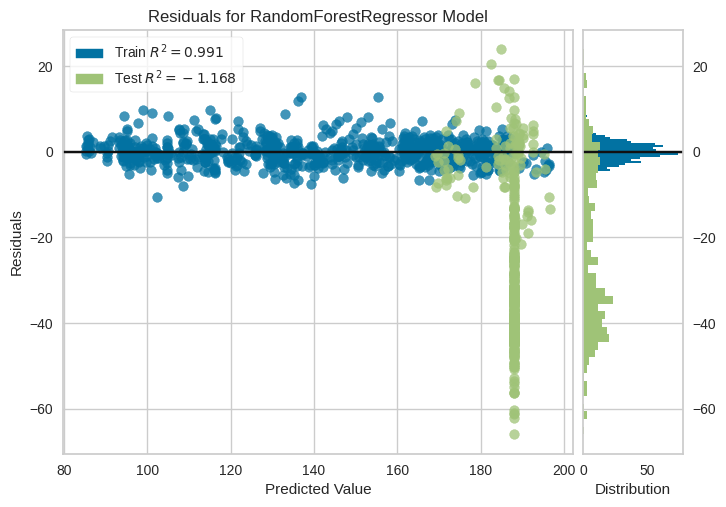

In [19]:
plot_model(tuned_rf)

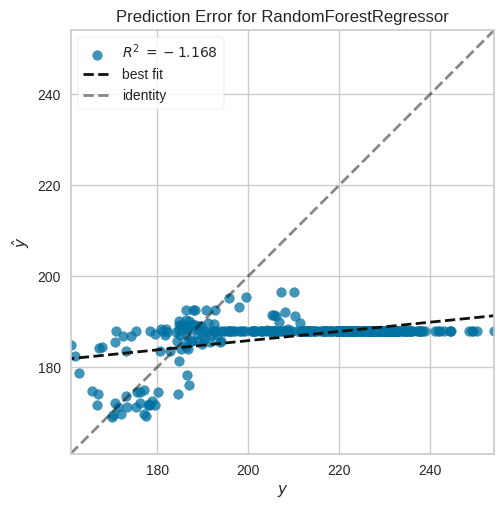

In [20]:
plot_model(tuned_rf, plot = 'error')

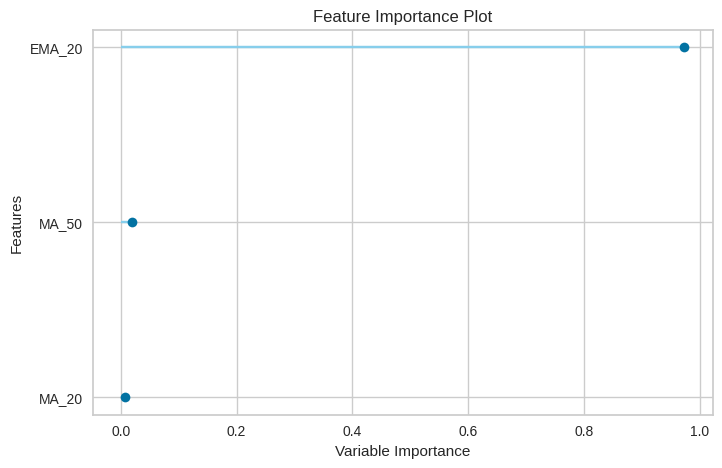

In [21]:
plot_model(tuned_rf, plot = 'feature')

In [22]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [23]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,25.6072,930.1423,30.4982,-1.1680,0.1465,0.1153


,MA_20,MA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-07-30 00:00:00-04:00,190.932007,187.082397,186.716476,181.710007,187.158766
2024-07-31 00:00:00-04:00,190.157501,187.044006,186.741577,186.979996,190.216278
2024-08-01 00:00:00-04:00,189.506500,187.089600,186.487137,184.070007,187.696125
2024-08-02 00:00:00-04:00,188.830505,187.100204,184.716934,167.899994,184.507846
2024-08-05 00:00:00-04:00,187.225494,186.795197,182.460083,161.020004,184.851695
...,...,...,...,...,...
2025-12-31 00:00:00-05:00,228.952499,231.149994,229.774429,230.820007,188.015948
2026-01-02 00:00:00-05:00,228.772507,231.436798,229.462585,226.500000,188.015948
2026-01-05 00:00:00-05:00,228.478500,231.526199,229.805191,233.059998,188.015948


In [24]:
final_rf = finalize_model(tuned_rf)

In [25]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['MA_20', 'MA_50', 'EMA_20'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(max_depth=9, min_impurity_decrease=0.1,
                                       min_samples_leaf=4, min_samples_split=7,
                                       n_jobs=-1, random_state=123))])


In [26]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.8644,14.9266,3.8635,0.9652,0.0187,0.0138


,MA_20,MA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-07-30 00:00:00-04:00,190.932007,187.082397,186.716476,181.710007,182.551182
2024-07-31 00:00:00-04:00,190.157501,187.044006,186.741577,186.979996,182.915829
2024-08-01 00:00:00-04:00,189.506500,187.089600,186.487137,184.070007,182.254449
2024-08-02 00:00:00-04:00,188.830505,187.100204,184.716934,167.899994,177.724887
2024-08-05 00:00:00-04:00,187.225494,186.795197,182.460083,161.020004,171.830472
...,...,...,...,...,...
2025-12-31 00:00:00-05:00,228.952499,231.149994,229.774429,230.820007,231.594196
2026-01-02 00:00:00-05:00,228.772507,231.436798,229.462585,226.500000,231.231333
2026-01-05 00:00:00-05:00,228.478500,231.526199,229.805191,233.059998,232.592399


In [27]:
unseenrf_predictions = predict_model(final_rf, data=data_test)
unseenrf_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.8644,14.9266,3.8635,0.9652,0.0187,0.0138


,MA_20,EMA_20,MA_50,Close,prediction_label
Date,,,,,
2024-07-30 00:00:00-04:00,190.932007,186.716476,187.082397,181.710007,182.551182
2024-07-31 00:00:00-04:00,190.157501,186.741577,187.044006,186.979996,182.915829
2024-08-01 00:00:00-04:00,189.506500,186.487137,187.089600,184.070007,182.254449
2024-08-02 00:00:00-04:00,188.830505,184.716934,187.100204,167.899994,177.724887
2024-08-05 00:00:00-04:00,187.225494,182.460083,186.795197,161.020004,171.830472
...,...,...,...,...,...
2025-12-31 00:00:00-05:00,228.952499,229.774429,231.149994,230.820007,231.594196
2026-01-02 00:00:00-05:00,228.772507,229.462585,231.436798,226.500000,231.231333
2026-01-05 00:00:00-05:00,228.478500,229.805191,231.526199,233.059998,232.592399


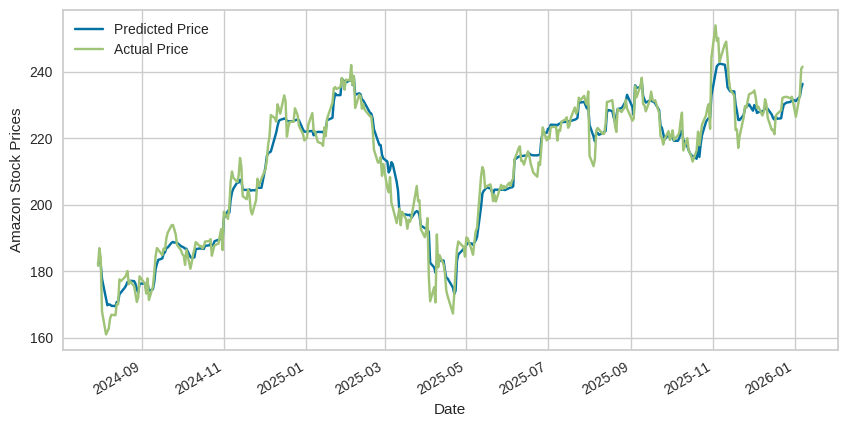

In [28]:
#Visualise Random Forest Regressor
predictedrf_price = pd.DataFrame(unseenrf_predictions,index=unseenrf_predictions.index,columns = ['prediction_label'])
predictedrf_price.plot(figsize=(10,5))
unseenrf_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Amazon Stock Prices")
plt.show()

#Comparison of performance against Linear Regression Model - See Cwk Documentation